##### Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Data Analytics Project\Data\superstore_cleaned.csv")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.shape

(9800, 18)

In [10]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

##### Sales Distrubution

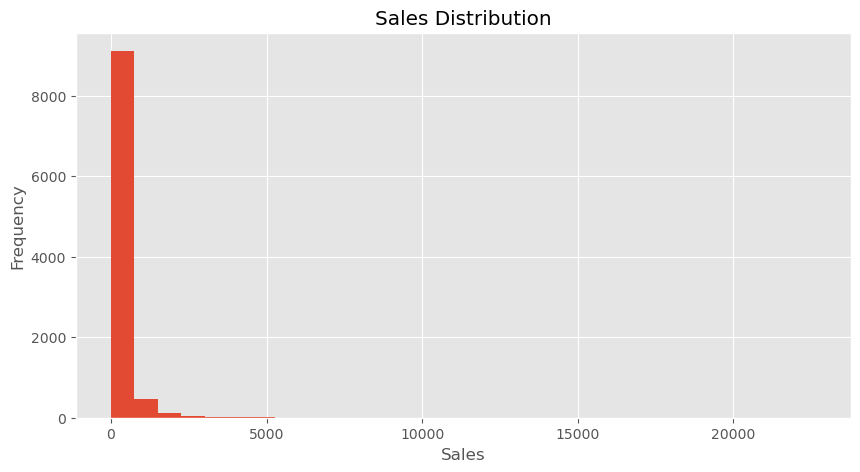

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

##### Business Insights
* Most orders have relatively low sales, while only a few orders generate very highly sales.
* The sales distribution is right-skewed, indicating that a small number of high-value transactions contribute significantly to total revenue

##### Recommendation
* Focus market effort on increasing the number of high-value purchase.
* Introduce product bundles or premium offering to increase the average order value.

##### Sales by Category

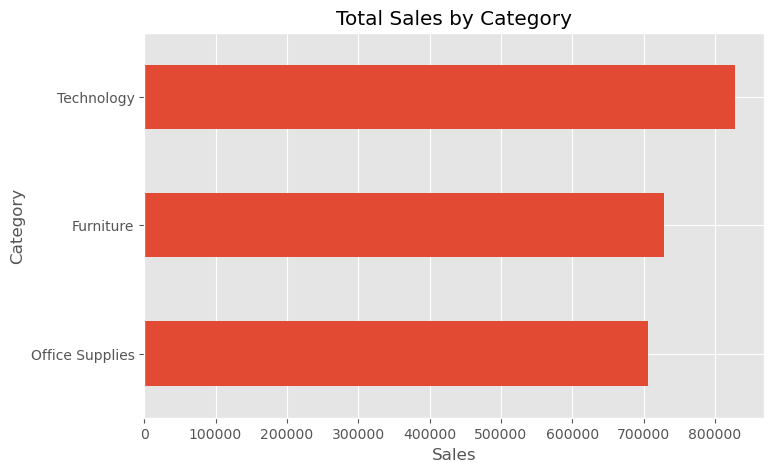

In [16]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

category_sales.plot(kind='barh', figsize=(8,5))
plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.show()

##### Business Insights
* The highest-selling category contributes the largest share of total revenue.
* Lower performing categories may require additional attention to improve sales performance.

##### Recommendation
* Increase invenotry and marketing investment for the top-performing category.
* Analyze customer preference in lower-performing categories and introduce targeted promotions or new procuts.

##### Sales by Region

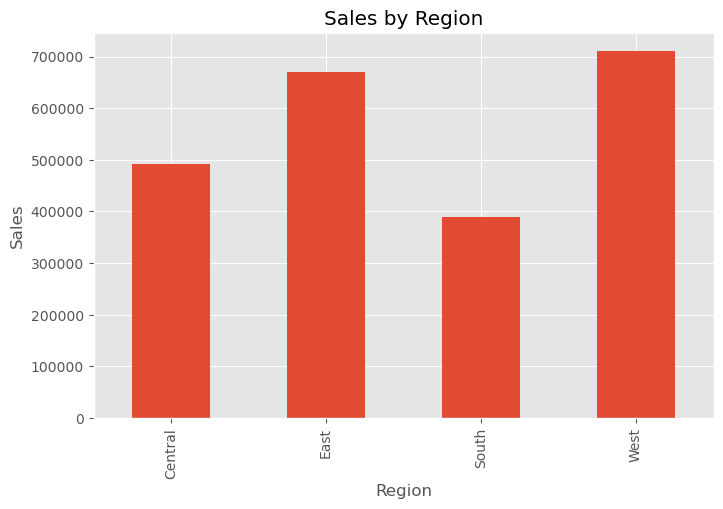

In [23]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

##### Business Insights
* Sales performance varies across diffrent regions.
* Some regions consistently generate higher revenue, while others have lower sales potential.

##### Recommendation
* Strengthen marketing campaigns in low-performing regions.
* Replicate successful sales strategies from high-performing regions to improve overall performance.

##### Top 10 States

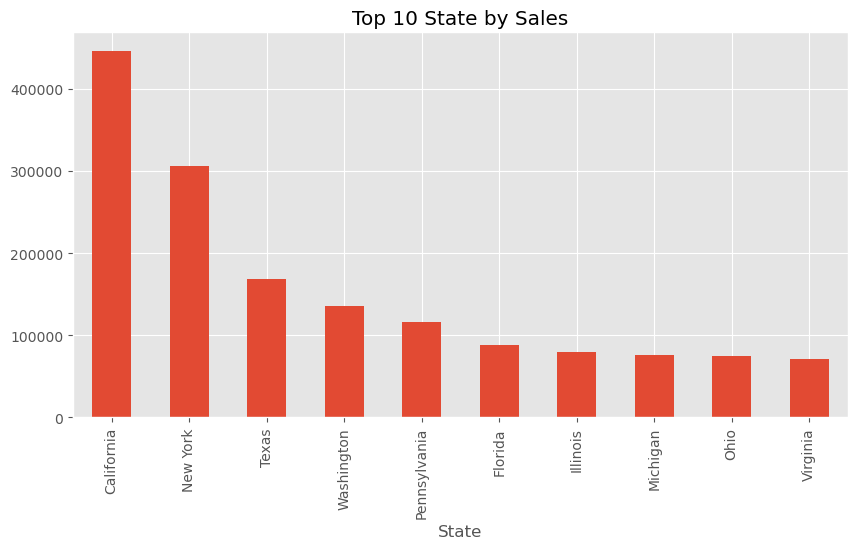

In [29]:
top_states = df.groupby("State")["Sales"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

top_states.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 State by Sales")
plt.show()

##### Business Insights
* A small number of state contribute a significant portion of total sales.
* These states represent key markets for the business.

##### Recommendation
* Prioritize inventory availability and customer service in high-performing states.
* Explore expansion opportunities and promotional campaigns in state with lower sales.

##### Top 10 Customers

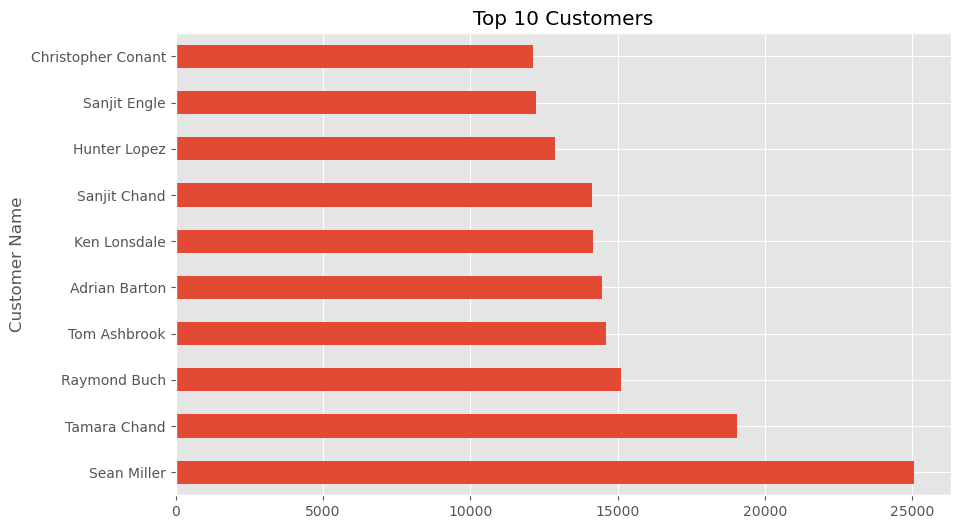

In [34]:
top_customers = df.groupby("Customer Name")["Sales"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

top_customers.plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Customers")
plt.show()

##### Business Insights
* A limited number of customers generate a subsatantial share of total revenue.
* These customers are valuable to the business and should be retained.

##### Recommendatiom
* Implement customer loyalty programs and personalized offers for top customers.
* Build long-term relationships through exclusive discounts and reward programs.

##### Top 10 Products

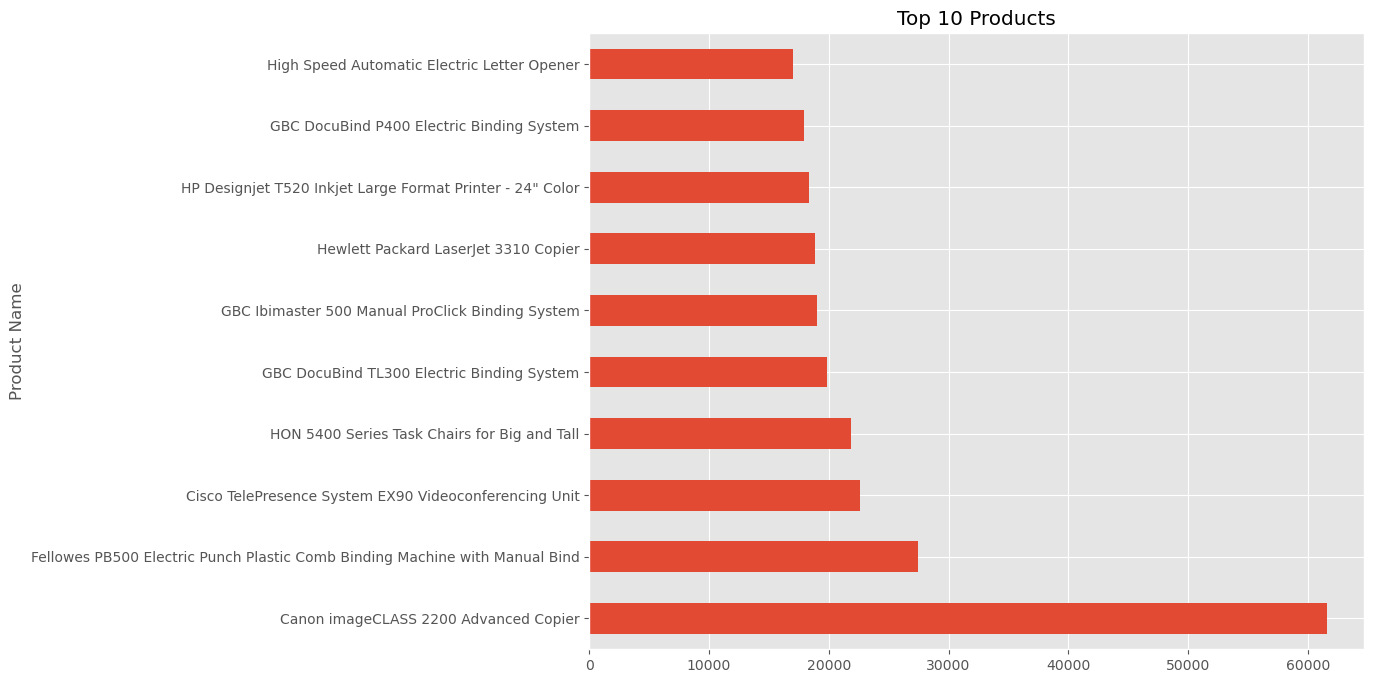

In [37]:
top_products = df.groupby("Product Name")["Sales"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

top_products.plot(kind="barh", figsize=(10,8))
plt.title("Top 10 Products")
plt.show()

##### Business Insight
* Certain products consistently outperform others in terms of sales.
* These products are the primary revenue drivers.

##### Recommendation
* Maintain adequate inventory levels for high-demand products.
* Promote related or complementary products through cross-selling strategies.

##### Montly Sales Trend

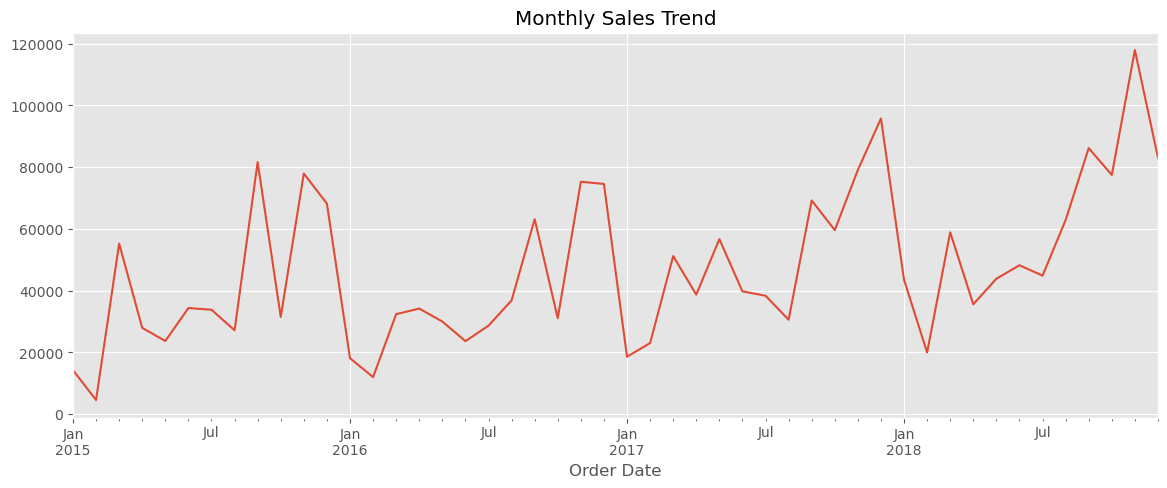

In [40]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(figsize=(14,5))
plt.title("Monthly Sales Trend")
plt.show()

##### Business Insights
* Monthly sales fluctuate throughout the year, with noticeable peak and low sales periods.
* Sesonal trends may influence customer purchasinf behavior.

##### Recommendation
* Increse inventory and marketing activities before peak sales months.
* Launch promotional campaigns during slower months to maintain consistent sales.

##### Ship Mode Analysis

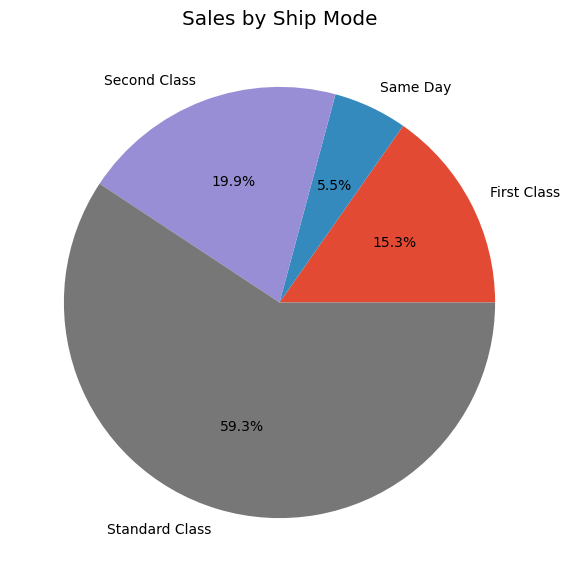

In [49]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum()

ship_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(7,7))
plt.ylabel("")
plt.title("Sales by Ship Mode")
plt.show()

##### Business Insights
* Customer show a clear preference for certain shipping methods.
* Some shipping modes contribute more to overall sales than others.

##### Recommendation
* Improve efficiency and service quality for the most frequently used shipping methods.
* Encourage customers to use cost-effective shipping options thorugh promotional offers.

##### Segment Analysis

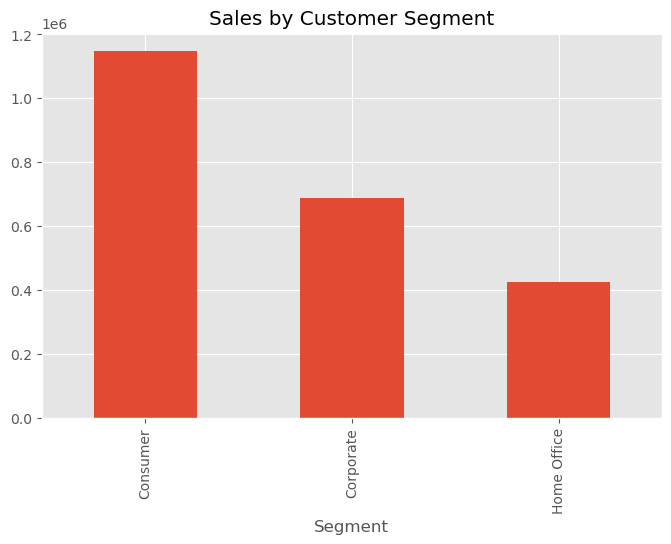

In [52]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Customer Segment")
plt.show()

##### Business Insight
* Customer segments contribute diffrently to total sales.
* One or two segments generate the majority of business revenue.

##### Recommendation
* Develop targeted marketing strategies for each customer segment.
* Focus customer retention efforts onn high-value segments while creating promotional campaigns to increase engagement in lower-performing segments.